In [111]:
import argparse
import csv
import json
import math
import random
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib

# matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import Tensor, nn

In [112]:
# These physical parameters intentionally mirror FEM-code-new.py.
T_FINAL = 5.0
A_STIM = 1.0
S_STIM = 0.12
X0, Y0 = 0.4, 0.0
# Diffusion 1 coefficients for healthy and scar tissue, respectively.
A_HEALTHY, A_SCAR = 0.1, 0.01
XA, YA, WA = -0.3, 0.0, 0.2
# Diffusion 2 coefficients for healthy and scar tissue, respectively.
A1, A2 = 0.8, 0.6 # x-direction and y-direction
#
R_VALUE = 1.0
# Regular-grid snapshots matching the defaults in PINN-code.py.
snapshot_times = np.asarray([0.0, 1.0, 2.0, 3.0, 4.0, 5.0], dtype=np.float64)

In [113]:
results_dir = Path("comparison_results")
results_dir.mkdir(exist_ok=True)

In [114]:
@dataclass(frozen=True)
class ModelSpec:
    hidden_layers: int
    hidden_width: int

class MonodomainPINN(nn.Module):
    """MLP approximation with an output transform enforcing u(x, y, 0)=u0."""

    def __init__(self, spec: ModelSpec) -> None:
        super().__init__()
        layers: list[nn.Module] = []
        input_width = 3
        for _ in range(spec.hidden_layers):
            linear = nn.Linear(input_width, spec.hidden_width)
            nn.init.xavier_normal_(linear.weight)
            nn.init.zeros_(linear.bias)
            layers.extend((linear, nn.Tanh()))
            input_width = spec.hidden_width
        output = nn.Linear(input_width, 1)
        nn.init.xavier_normal_(output.weight)
        nn.init.zeros_(output.bias)
        layers.append(output)
        self.network = nn.Sequential(*layers)

    def forward(self, points: Tensor) -> Tensor:
        x = points[:, 0:1]
        y = points[:, 1:2]
        t = points[:, 2:3]
        # With time normalization, the network sees t in [-1, 1] instead of [0, T_FINAL].
        normalized = torch.cat((x, y, 2.0 * t / T_FINAL - 1.0), dim=1)
        raw = self.network(normalized)
        # Without the time normalization, the network sees t in [0, T_FINAL].
        # inputs = torch.cat((x, y, t), dim=1)
        # raw = self.network(inputs)

        # This reaction-aware transform is exactly u0 at t=0 while leaving the
        # network free to represent the solution for every t>0.
        reaction_decay = torch.exp(-R_VALUE * t)
        return reaction_decay * initial_condition(x, y) + (1.0 - reaction_decay) * raw


The old diffusivity was a scalar spatial function:

$$a(x,y)=A_{\mathrm{healthy}}
-(A_{\mathrm{healthy}}-A_{\mathrm{scar}})
\exp\left[-\frac{(x-X_A)^2+(y-Y_A)^2}{2W_A^2}\right].$$

It transitions from A_SCAR = 0.01 near the scar centre to A_HEALTHY = 0.1 away from it.

In [115]:
def initial_condition(x: Tensor, y: Tensor) -> Tensor:
    radius_sq = (x - X0) ** 2 + (y - Y0) ** 2
    return A_STIM * torch.exp(-radius_sq / (2.0 * S_STIM**2))

# def diffusivity(x: Tensor, y: Tensor) -> Tensor:
#     scar_radius_sq = (x - XA) ** 2 + (y - YA) ** 2
#     scar = torch.exp(-scar_radius_sq / (2.0 * WA**2))
#     return A_HEALTHY - (A_HEALTHY - A_SCAR) * scar

def diffusivity(x: Tensor, y: Tensor) -> Tensor:
    a1 = torch.full_like(x, A1)
    a2 = torch.full_like(y, A2)
    return torch.cat((a1, a2), dim=1)

def sample_times(count: int, device: torch.device, dtype: torch.dtype,
                 early_time_fraction: float) -> Tensor:
    uniform_draw = torch.rand((count, 1), device=device, dtype=dtype)
    early_draw = torch.rand((count, 1), device=device, dtype=dtype)
    choose_early = torch.rand((count, 1), device=device) < early_time_fraction
    # Squaring a uniform draw concentrates samples near the rapid initial transient.
    return T_FINAL * torch.where(choose_early, early_draw.square(), uniform_draw)

def sample_interior(count: int, device: torch.device, dtype: torch.dtype,
                    early_time_fraction: float) -> Tensor:
    radius = torch.sqrt(torch.rand((count, 1), device=device, dtype=dtype))
    angle = 2.0 * math.pi * torch.rand((count, 1), device=device, dtype=dtype)
    x = radius * torch.cos(angle)
    y = radius * torch.sin(angle)
    t = sample_times(count, device, dtype, early_time_fraction)
    return torch.cat((x, y, t), dim=1)


def sample_boundary(count: int, device: torch.device, dtype: torch.dtype,
                    early_time_fraction: float) -> Tensor:
    angle = 2.0 * math.pi * torch.rand((count, 1), device=device, dtype=dtype)
    x = torch.cos(angle)
    y = torch.sin(angle)
    t = sample_times(count, device, dtype, early_time_fraction)
    return torch.cat((x, y, t), dim=1)

In [116]:
def gradient(value: Tensor, points: Tensor, create_graph: bool = True) -> Tensor:
    result = torch.autograd.grad(
        value,
        points,
        grad_outputs=torch.ones_like(value),
        create_graph=create_graph,
        retain_graph=True,
    )[0]
    return result

def pde_residual(model: MonodomainPINN, points: Tensor) -> Tensor:
    points = points.detach().requires_grad_(True)
    u = model(points)
    grad_u = gradient(u, points)
    u_x, u_y, u_t = grad_u[:, 0:1], grad_u[:, 1:2], grad_u[:, 2:3]
    a = diffusivity(points[:, 0:1], points[:, 1:2])
    a1, a2 = a[:, 0:1], a[:, 1:2]

    flux_x, flux_y = a1 * u_x, a2 * u_y
    div_flux = gradient(flux_x, points)[:, 0:1] + gradient(flux_y, points)[:, 1:2]
    return u_t - div_flux + R_VALUE * u

def boundary_flux(model: MonodomainPINN, points: Tensor) -> Tensor:
    points = points.detach().requires_grad_(True)
    u = model(points)
    grad_u = gradient(u, points)
    a = diffusivity(points[:, 0:1], points[:, 1:2])
    a1, a2 = a[:, 0:1], a[:, 1:2]
    # On the unit circle the outward unit normal is n=(x,y).
    return  (a1 * grad_u[:, 0:1] * points[:, 0:1] +
            a2 * grad_u[:, 1:2] * points[:, 1:2]
            )

In [117]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [118]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")    

Using device: mps


In [119]:
dtype = torch.float32 #torch.float64
if device.type == "mps" and dtype == torch.float64:
    raise ValueError("MPS does not support float64; use --dtype float32")
torch.set_default_dtype(dtype)

In [120]:
set_seed(42)

In [121]:
hidden_layers       = 5
hidden_width        = 128
learning_rate       = 1.0e-3
epochs              = 12000
min_learning_rate   = 1.0e-5
#
interior_batch      = 8192 #4096 #2048
boundary_batch      = 512
early_time_fraction = 0.5
#
boundary_weight     = 10.0
grad_clip           = 1.0
log_every           = 100

In [122]:
# args.output_dir.mkdir(parents=True, exist_ok=True)

spec = ModelSpec(hidden_layers, hidden_width)
model = MonodomainPINN(spec).to(device=device, dtype=dtype)
# initial_error = validate_setup(model, device, dtype, args.early_time_fraction)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=epochs, eta_min=min_learning_rate
)

In [123]:
print(f"device={device}, dtype={dtype}, parameters={sum(p.numel() for p in model.parameters()):,}")
# print(f"maximum initial-condition error: {initial_error:.3e}")

device=mps, dtype=torch.float32, parameters=66,689


In [ ]:
history: list[dict[str, float]] = []
best_loss = math.inf
best_epoch = 0
best_losses: dict[str, float] = {}
best_state: dict[str, Tensor] | None = None

for epoch in range(1, epochs + 1):
    model.train()
    interior = sample_interior(
        interior_batch, device, dtype, early_time_fraction
    )
    boundary = sample_boundary(
        boundary_batch, device, dtype, early_time_fraction
    )
    residual = pde_residual(model, interior)
    flux = boundary_flux(model, boundary)
    pde_loss = residual.square().mean()
    boundary_loss = flux.square().mean()
    total_loss = pde_loss + boundary_weight * boundary_loss

    if not torch.isfinite(total_loss):
        raise RuntimeError(f"Non-finite loss at epoch {epoch}")
    optimizer.zero_grad(set_to_none=True)
    total_loss.backward()
    gradient_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    if not torch.isfinite(gradient_norm):
        raise RuntimeError(f"Non-finite gradient at epoch {epoch}")
    optimizer.step()
    scheduler.step()

    losses = {
        "total_loss": float(total_loss.detach().cpu()),
        "pde_loss": float(pde_loss.detach().cpu()),
        "boundary_loss": float(boundary_loss.detach().cpu()),
    }
    row = {
        "epoch": epoch,
        **losses,
        "learning_rate": scheduler.get_last_lr()[0],
        "gradient_norm": float(gradient_norm.detach().cpu()),
    }
    history.append(row)
    if losses["total_loss"] < best_loss:
        best_loss = losses["total_loss"]
        best_epoch = epoch
        best_losses = losses
        best_state = {name: value.detach().cpu().clone()
                        for name, value in model.state_dict().items()}

    if epoch == 1 or epoch % log_every == 0 or epoch == epochs:
        print(
            f"epoch {epoch:6d}/{epochs}  total={losses['total_loss']:.4e}  "
            f"pde={losses['pde_loss']:.4e}  boundary={losses['boundary_loss']:.4e}  "
            f"lr={row['learning_rate']:.2e}"
        )

epoch      1/12000  total=1.1794e+01  pde=1.1770e+01  boundary=2.4880e-03  lr=1.00e-03
epoch    100/12000  total=1.6300e+01  pde=1.6299e+01  boundary=1.9904e-05  lr=1.00e-03
epoch    200/12000  total=1.1315e+01  pde=1.1314e+01  boundary=5.1063e-05  lr=9.99e-04
epoch    300/12000  total=1.0180e+01  pde=1.0168e+01  boundary=1.2052e-03  lr=9.98e-04
epoch    400/12000  total=4.7740e+00  pde=4.7657e+00  boundary=8.3080e-04  lr=9.97e-04
epoch    500/12000  total=2.5645e+00  pde=2.5544e+00  boundary=1.0083e-03  lr=9.96e-04
epoch    600/12000  total=2.7131e+00  pde=2.7102e+00  boundary=2.8980e-04  lr=9.94e-04
epoch    700/12000  total=1.1550e+00  pde=1.1517e+00  boundary=3.3107e-04  lr=9.92e-04
epoch    800/12000  total=9.7381e-01  pde=9.7121e-01  boundary=2.6007e-04  lr=9.89e-04
epoch    900/12000  total=1.6817e+00  pde=1.6780e+00  boundary=3.6271e-04  lr=9.86e-04
epoch   1000/12000  total=1.2539e+00  pde=1.2486e+00  boundary=5.3083e-04  lr=9.83e-04
epoch   1100/12000  total=6.3802e-01  pde=6

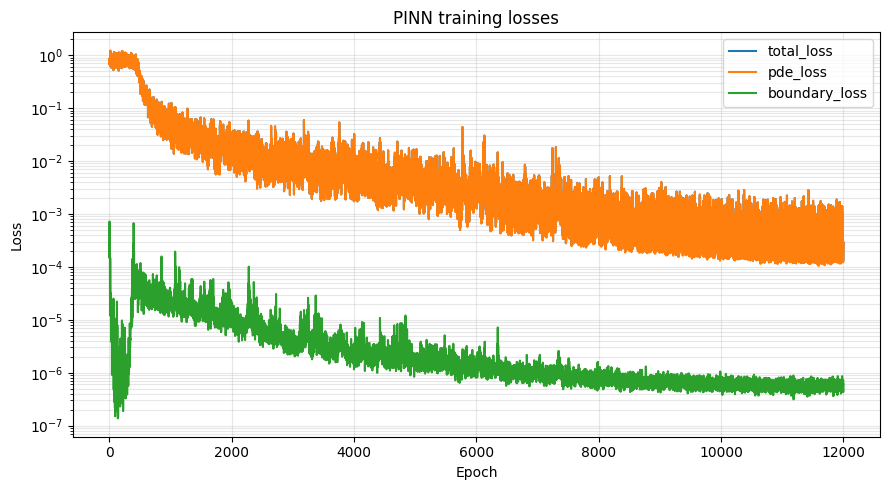

In [ ]:
epochs_history = [row["epoch"] for row in history]

plt.figure(figsize=(9, 5))

for loss_name in ("total_loss", "pde_loss", "boundary_loss"):
    plt.plot(
        epochs_history,
        [row[loss_name] for row in history],
        label=loss_name,
        linewidth=1.5,
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")  # Useful because the losses differ greatly in magnitude
plt.title("PINN training losses")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
final_losses = {key: history[-1][key]
                    for key in ("total_loss", "pde_loss", "boundary_loss")}

In [ ]:
results_dir = Path("comparison_results")
points_xy = np.atleast_2d(
    np.loadtxt(results_dir / "comparison_points.txt")
)

In [ ]:

# Optional: evaluate the best model found during training
# model.load_state_dict(best_state)

In [ ]:
snapshot_values = np.empty(
    (len(snapshot_times), len(points_xy)),
    dtype=np.float64,
)

In [ ]:
was_training = model.training
model.eval()

MonodomainPINN(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [ ]:
with torch.inference_mode():
    for i, time in enumerate(snapshot_times):
        # PINN inputs have columns (x, y, t)
        points_xyt = np.column_stack((
            points_xy,
            np.full(len(points_xy), time),
        ))

        inputs = torch.as_tensor(
            points_xyt,
            device=device,
            dtype=dtype,
        )

        snapshot_values[i] = (
            model(inputs)
            .squeeze(-1)
            .cpu()
            .numpy()
        )

model.train(was_training)

MonodomainPINN(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [ ]:
output_file = results_dir / "pinn_comparison_snapshots.npz"

np.savez_compressed(
    output_file,
    points=points_xy,             # (n_points, 2)
    times=snapshot_times,         # (n_times,)
    u=snapshot_values,            # (n_times, n_points)
)

print(f"Saved PINN results to {output_file}")

Saved PINN results to comparison_results/pinn_comparison_snapshots.npz
